# Exploratory Data Analysis (EDA) for GCP Pose Estimation

This notebook performs exploratory data analysis on the Skylark Drones GCP dataset, including:

- Dataset statistics
- Annotation analysis
- Shape distribution
- Missing labels
- Image resolutions
- Coordinate distributions
- Visualization of GCP markers
- Dataset preparation for training

In [1]:
import os
import json
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from tqdm import tqdm

In [2]:
TRAIN_DIR = "../train_dataset"
TEST_DIR = "../test_dataset"

JSON_PATH = os.path.join(
    TRAIN_DIR,
    "gcp_marks.json"
)

print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)
print("JSON path:", JSON_PATH)
print("JSON exists:", os.path.exists(JSON_PATH))

Train directory: ../train_dataset
Test directory: ../test_dataset
JSON path: ../train_dataset\gcp_marks.json
JSON exists: True


# Load Dataset

In [3]:
with open(JSON_PATH, "r") as f:
    data = json.load(f)

print("Total annotations:", len(data))

Total annotations: 1000


In [4]:
sample_key = list(data.keys())[0]

print("Image Path:")
print(sample_key)

print("\nAnnotation:")
print(data[sample_key])

Image Path:
scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG

Annotation:
{'mark': {'x': 3272.769145523532, 'y': 1089.3292198344861}, 'verified_shape': 'Cross'}


# Shape Distribution Analysis

In [5]:
shape_counts = Counter()

for v in data.values():

    if "verified_shape" in v:
        shape_counts[
            v["verified_shape"]
        ] += 1

shape_counts

Counter({'L-Shape': 491, 'Square': 328, 'Cross': 177})

In [6]:
missing = []

for k, v in data.items():

    if "verified_shape" not in v:
        missing.append((k, v))

print("Total missing:", len(missing))

for i, item in enumerate(missing):

    print(f"\nExample {i+1}:")
    print(item)

Total missing: 4

Example 1:
('Seashell Ras el Hekma/Survey 3/GCP12/DJI_20240605112759_0254.JPG', {'mark': {'x': 2674.8615461670306, 'y': 427.01017187573916}})

Example 2:
('Vedanta GOA Bicholim/MCDR 2024/GCP32/19_4_DJI_0066.JPG', {'mark': {'x': 3191.64937365544, 'y': 1634.5713599497808}})

Example 3:
('Vedanta GOA Bicholim/MCDR 2024/GCP17/12_2_DJI_0558.JPG', {'mark': {'x': 507.906900565024, 'y': 2123.0392188877872}})

Example 4:
('UTCL UNCL Additional Area/Survey-1/GCP-98/DJI_20240425131303_0192_V.JPG', {'mark': {'x': 1924.1735694119093, 'y': 267.03431372548926}})


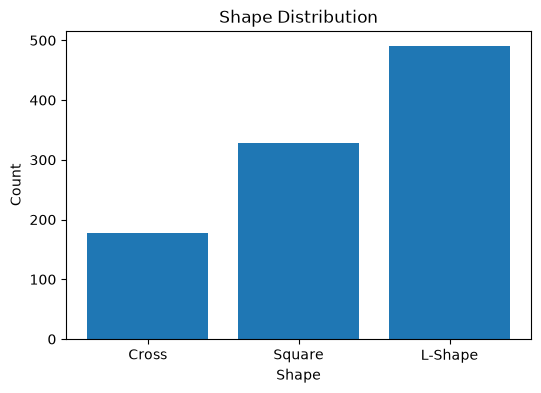

In [7]:
plt.figure(figsize=(6,4))

plt.bar(
    shape_counts.keys(),
    shape_counts.values()
)

plt.title("Shape Distribution")
plt.xlabel("Shape")
plt.ylabel("Count")

plt.show()

# Dataset Statistics

In [8]:
projects = set()

for k in data.keys():
    projects.add(
        k.split("/")[0]
    )

print(
    "Number of projects:",
    len(projects)
)

print("\nProjects:")
print(sorted(projects))

Number of projects: 11

Projects:
['231129_CTD', 'Adani GP-III CG', 'Deora Limestone Mine', 'Egypt-New city', 'RDCW-Reddipalayam Limestone Mine', 'Seashell Ras el Hekma', 'UTCL UNCL Additional Area', 'Vedanta GOA Bicholim', 'scout_966', 'scout_971', 'scout_973']


In [9]:
resolutions = Counter()

sample_keys = list(data.keys())[:500]

for path in tqdm(sample_keys):

    img = cv2.imread(
        os.path.join(
            TRAIN_DIR,
            path
        )
    )

    if img is not None:

        h, w = img.shape[:2]

        resolutions[
            (w, h)
        ] += 1

print(resolutions)

100%|██████████| 500/500 [00:39<00:00, 12.66it/s]

Counter({(4096, 2730): 341, (4096, 3068): 159})


In [10]:
xs = []
ys = []

for v in data.values():

    xs.append(
        v["mark"]["x"]
    )

    ys.append(
        v["mark"]["y"]
    )

print(
    "X range:",
    min(xs),
    "to",
    max(xs)
)

print(
    "Y range:",
    min(ys),
    "to",
    max(ys)
)

X range: 66.96412957110547 to 3937.0554836417386
Y range: 35.044623574285524 to 2914.109404383081


# Visualizations

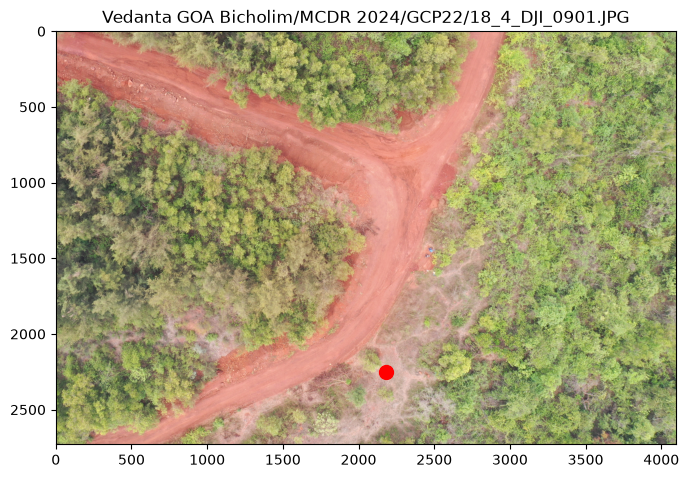

In [11]:
sample = random.choice(
    list(data.keys())
)

img = cv2.imread(
    os.path.join(
        TRAIN_DIR,
        sample
    )
)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

x = data[sample]["mark"]["x"]
y = data[sample]["mark"]["y"]

plt.figure(figsize=(8,8))
plt.imshow(img)

plt.scatter(
    [x],
    [y],
    c="red",
    s=100
)

plt.title(sample)

plt.show()

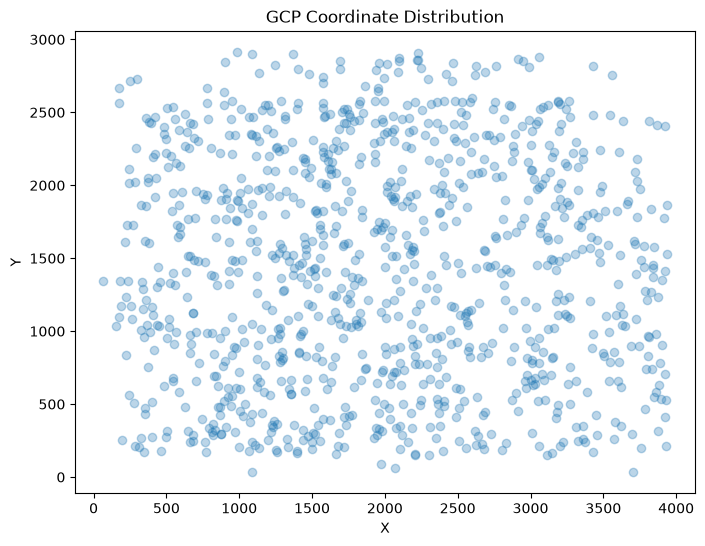

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    xs,
    ys,
    alpha=0.3
)

plt.title(
    "GCP Coordinate Distribution"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.show()

# Dataset Preparation

In [13]:
shape_to_idx = {
    "Cross": 0,
    "Square": 1,
    "L-Shape": 2
}

idx_to_shape = {
    v: k
    for k, v in shape_to_idx.items()
}

print(shape_to_idx)
print(idx_to_shape)

{'Cross': 0, 'Square': 1, 'L-Shape': 2}
{0: 'Cross', 1: 'Square', 2: 'L-Shape'}


In [14]:
records = []

for path, info in data.items():

    if "verified_shape" not in info:
        continue

    records.append({
        "path": path,
        "x": info["mark"]["x"],
        "y": info["mark"]["y"],
        "shape": info["verified_shape"]
    })

df = pd.DataFrame(records)

df.head()

,path,x,y,shape
0,scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_...,3272.769146,1089.329220,Cross
1,RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_...,2991.971596,2445.860741,Cross
2,RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_...,2687.926479,1552.879752,Cross
3,RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_...,2862.995819,792.509426,Cross
4,RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_...,2486.411284,607.232596,Cross


In [15]:
print(
    "Total usable samples:",
    len(df)
)

print(
    "\nShape counts:"
)

print(
    df["shape"].value_counts()
)

Total usable samples: 996

Shape counts:
shape
L-Shape    491
Square     328
Cross      177
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["shape"],
    random_state=42
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "\nValidation distribution:"
)

print(
    val_df["shape"].value_counts()
)

Train: 796
Validation: 200

Validation distribution:
shape
L-Shape    99
Square     66
Cross      35
Name: count, dtype: int64


# PyTorch Environment Check

In [17]:
import torch
import torchvision
import albumentations as A

print(
    "Torch:",
    torch.__version__
)

print(
    "Torchvision:",
    torchvision.__version__
)

print(
    "Albumentations:",
    A.__version__
)

Torch: 2.12.0+cpu
Torchvision: 0.27.0+cpu
Albumentations: 2.0.8


In [18]:
print(
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        torch.cuda.get_device_name(0)
    )

False


# Dataset and Model Validation

In [19]:
import sys
sys.path.append("../src")

In [20]:
from dataset import GCPDataset
from transforms import (
    get_train_transforms
)

dataset = GCPDataset(
    train_df,
    TRAIN_DIR,
    transform=get_train_transforms()
)

sample = dataset[0]

print(
    sample["image"].shape
)

print(
    sample["coords"]
)

print(
    sample["label"]
)

torch.Size([3, 512, 512])
tensor([0.3039, 0.8250])
tensor(1)


In [21]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

batch = next(
    iter(loader)
)

print(
    "Image batch:",
    batch["image"].shape
)

print(
    "Coords batch:",
    batch["coords"].shape
)

print(
    "Label batch:",
    batch["label"].shape
)

Image batch: torch.Size([8, 3, 512, 512])
Coords batch: torch.Size([8, 2])
Label batch: torch.Size([8])


In [22]:
from model import GCPModel

model = GCPModel()

x = torch.randn(
    1,
    3,
    512,
    512
)

coords, logits = model(x)

print(
    "Coords shape:",
    coords.shape
)

print(
    "Coords:",
    coords
)

print(
    "Logits shape:",
    logits.shape
)

print(
    "Logits:",
    logits
)

Coords shape: torch.Size([1, 2])
Coords: tensor([[0.5012, 0.4824]], grad_fn=<SigmoidBackward0>)
Logits shape: torch.Size([1, 3])
Logits: tensor([[-0.0021,  0.0431, -0.0077]], grad_fn=<AddmmBackward0>)


In [23]:
from sklearn.utils.class_weight import compute_class_weight

labels = train_df["shape"].map(
    shape_to_idx
).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1,2]),
    y=labels
)

print(weights)

[1.8685446  1.01272265 0.67687075]


# EDA Summary

Key findings:

- Dataset contains 1000 annotations, with 996 usable samples.
- Four samples have missing shape labels and were excluded.
- Class imbalance exists:
  - Cross: 177
  - Square: 328
  - L-Shape: 491
- Images have two major resolutions:
  - 4096 × 2730
  - 4096 × 3068
- Coordinates span nearly the entire image space.
- Stratified train-validation split was used.
- Class weights were computed to mitigate imbalance.